In [48]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


In [49]:
import json

In [53]:
player_input = widgets.Text(
    placeholder='Enter player name',
    description='Player:',
    style={'description_width': 'initial'}
)

output = widgets.Output()

def search_player(change):
    name = player_input.value.strip()
    if not name:
        return

    with output:
        output.clear_output(wait=True)

        # Get player stats
        stats_response = requests.get(f"http://localhost:8080/api/players/{name}")
        if stats_response.status_code != 200:
            print(f"Player {name} not found.")
            return

        stats = stats_response.json()

        # Get ML prediction
        import json
        pred_response = requests.get(f"http://localhost:8080/api/players/{name}/predict")
        prediction = json.loads(pred_response.text)


        # Display stats
        print(f"=== {stats['name']} ===")
        print(f"Game:       {stats['game']}")
        print(f"KD Ratio:   {stats['kdRatio']}")
        print(f"Win Rate:   {stats['winRate']}")
        print(f"Tier:       {prediction['predictionTier']}")
        print(f"Confidence: {prediction['confidence']*100:.0f}%")

        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].bar(['KD Ratio'], [stats['kdRatio']], color='steelblue')
        axes[0].set_ylim([0, 5])
        axes[0].set_title('KD Ratio')

        axes[1].bar(['Win Rate'], [stats['winRate']], color='green')
        axes[1].set_ylim([0, 1])
        axes[1].set_title('Win Rate')

        plt.suptitle(
            f"{stats['name']} — {prediction['predictionTier']} "
            f"({prediction['confidence']*100:.0f}% confidence)"
        )
        plt.tight_layout()
        plt.show()

player_input.observe(search_player, names='value')
display(player_input, output)

Text(value='', description='Player:', placeholder='Enter player name', style=TextStyle(description_width='init…

Output()

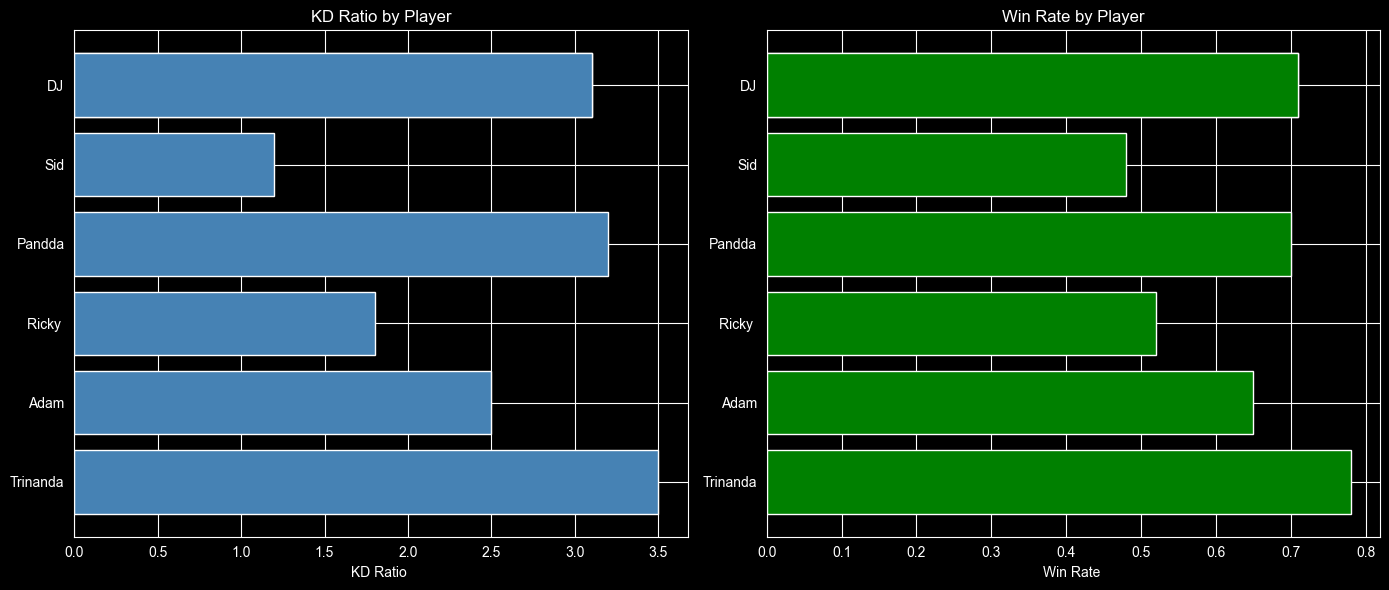

In [51]:
response=requests.get("http://localhost:8080/api/players")
df=pd.DataFrame(response.json())

fig,axes=plt.subplots(1,2,figsize=(14,6))

axes[0].barh(df['name'], df['kdRatio'], color='steelblue')
axes[0].set_title('KD Ratio by Player')
axes[0].set_xlabel('KD Ratio ')

axes[1].barh(df['name'], df['winRate'], color='green')
axes[1].set_title('Win Rate by Player')
axes[1].set_xlabel('Win Rate ')

plt.tight_layout()
plt.show()

